In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("/sample_data.csv")

In [ ]:
data

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Packet Length Mean,Packet Length Std,Average Packet Size,Label
0,23507,2,2,92,254,46.000000,127.00,1.471902e+04,170.162079,7.835667e+03,1.352676e+04,23455,3,78.400000,44.365527,98.000000,Benign
1,52645,3,4,1064,297,354.666667,74.25,2.585241e+04,132.966094,8.774167e+03,1.202066e+04,24456,4,170.125000,375.835237,194.428571,Benign
2,33769,1,1,55,110,55.000000,110.00,4.886138e+03,59.225917,3.376900e+04,0.000000e+00,33769,33769,73.333333,31.754265,110.000000,Benign
3,150,2,2,62,118,31.000000,59.00,1.200000e+06,26666.666670,5.000000e+01,8.573797e+01,149,0,42.200000,15.336232,52.750000,Benign
4,84565,3,6,310,11595,103.333333,1932.50,1.407793e+05,106.427009,1.057062e+04,2.626047e+04,75110,50,1190.500000,1888.989104,1322.777778,Malicious
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,5214727,5,4,794,557,158.800000,139.25,2.590740e+02,1.725881,6.518409e+05,1.667271e+06,4775099,26,135.100000,216.130336,150.111111,Benign
249996,120240,1,1,51,158,51.000000,158.00,1.738190e+03,16.633400,1.202400e+05,0.000000e+00,120240,120240,86.666667,61.776479,130.000000,Benign
249997,154462,3,6,372,11595,124.000000,1932.50,7.747537e+04,58.266758,1.930775e+04,4.905772e+04,140118,4,1196.700000,1885.877223,1329.666667,Malicious
249998,97780719,2,1,486,6,243.000000,6.00,5.031667e+00,0.030681,4.890000e+07,6.910000e+07,97800000,7,123.000000,242.016528,164.000000,Malicious


In [ ]:
df = pd.read_csv("/sample_data.csv")

# Clean column names (remove spaces)
df.columns = df.columns.str.strip()

# Check
print(df.head())
print(df.info())

   Flow Duration  Total Fwd Packets  Total Backward Packets  \
0          23507                  2                       2   
1          52645                  3                       4   
2          33769                  1                       1   
3            150                  2                       2   
4          84565                  3                       6   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           92                          254   
1                         1064                          297   
2                           55                          110   
3                           62                          118   
4                          310                        11595   

   Fwd Packet Length Mean  Bwd Packet Length Mean  Flow Bytes/s  \
0               46.000000                  127.00  1.471902e+04   
1              354.666667                   74.25  2.585241e+04   
2               55.000000                

In [ ]:
print(df.shape)
print(df.columns)
print(df.describe())
print(df['Label'].value_counts())

(250000, 17)
Index(['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Packet Length Mean', 'Packet Length Std',
       'Average Packet Size', 'Label'],
      dtype='object')
       Flow Duration  Total Fwd Packets  Total Backward Packets  \
count   2.500000e+05      250000.000000           250000.000000   
mean    3.210958e+07           8.897008                9.247340   
std     4.340035e+07         538.895862              717.111638   
min    -4.000000e+00           1.000000                0.000000   
25%     4.864775e+04           2.000000                1.000000   
50%     2.007016e+06           4.000000                4.000000   
75%     8.447227e+07           7.000000                6.000000   
max     1.200000e+08      199565.0

In [ ]:
df['Label'] = df['Label'].str.upper()

In [ ]:
label_col = 'Label'

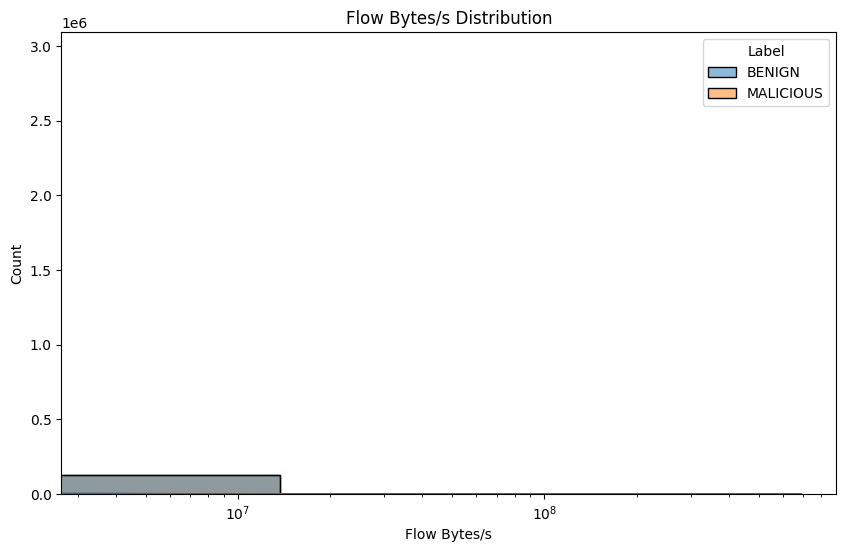

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Flow Bytes/s', hue='Label', bins=50, kde=True)
plt.xscale('log')  # very important for skewed data
plt.title('Flow Bytes/s Distribution')
plt.show()

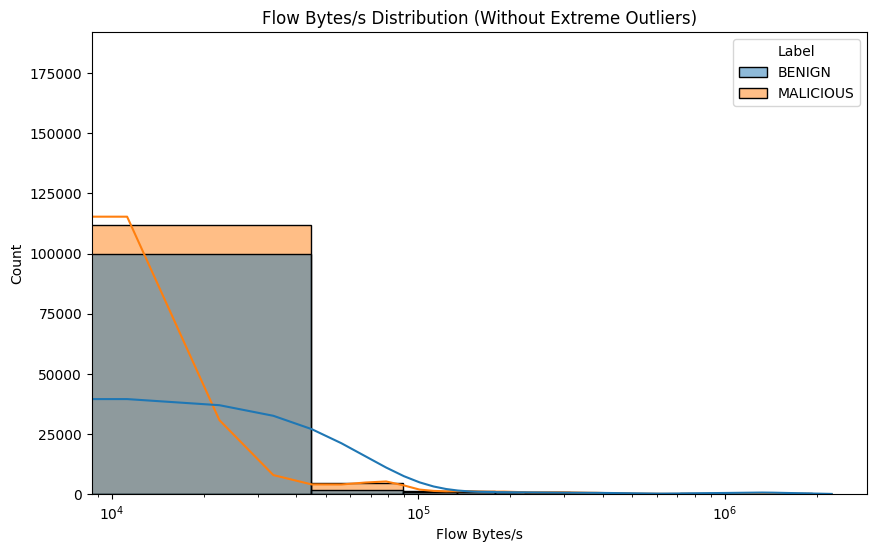

In [ ]:
# Remove top 1% extreme values
upper_limit = df['Flow Bytes/s'].quantile(0.99)

filtered_df = df[df['Flow Bytes/s'] <= upper_limit]

plt.figure(figsize=(10,6))
sns.histplot(data=filtered_df, x='Flow Bytes/s', hue='Label', bins=50, kde=True)
plt.xscale('log')
plt.title('Flow Bytes/s Distribution (Without Extreme Outliers)')
plt.show()

In [ ]:
print(df['Flow Bytes/s'].describe())

print("NaN:", df['Flow Bytes/s'].isna().sum())
print("Zeros:", (df['Flow Bytes/s'] == 0).sum())
print("Inf:", np.isinf(df['Flow Bytes/s']).sum())

count    2.500000e+05
mean     2.005765e+05
std      3.477290e+06
min      0.000000e+00
25%      1.196671e+02
50%      3.907646e+02
75%      9.438182e+03
max      6.880000e+08
Name: Flow Bytes/s, dtype: float64
NaN: 0
Zeros: 12769
Inf: 0


In [ ]:
df_clean = df[df['Flow Bytes/s'] > 0]

In [ ]:
lower = df_clean['Flow Bytes/s'].quantile(0.01)
upper = df_clean['Flow Bytes/s'].quantile(0.99)

df_clean = df_clean[
    (df_clean['Flow Bytes/s'] >= lower) &
    (df_clean['Flow Bytes/s'] <= upper)
]

In [ ]:
df_sample = df_clean.sample(10000, random_state=42)

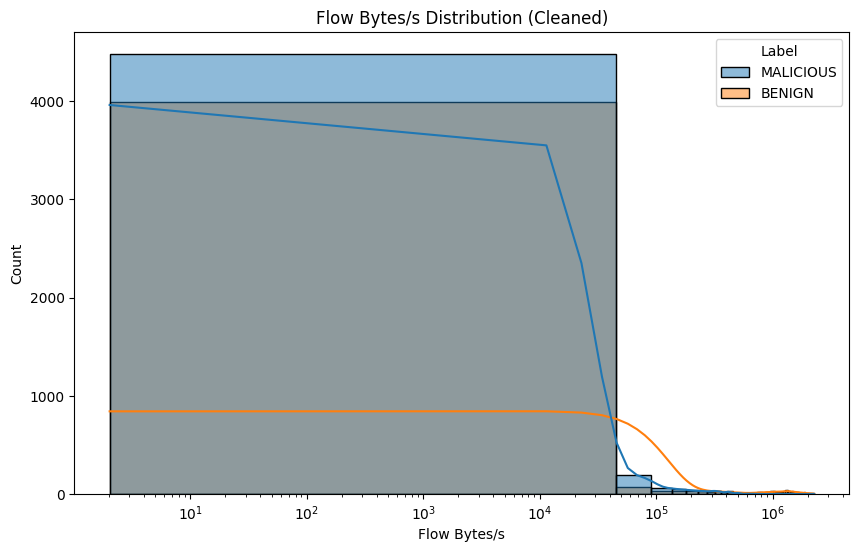

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_sample,
    x='Flow Bytes/s',
    hue='Label',
    bins=50,
    kde=True
)

plt.xscale('log')
plt.title('Flow Bytes/s Distribution (Cleaned)')
plt.show()

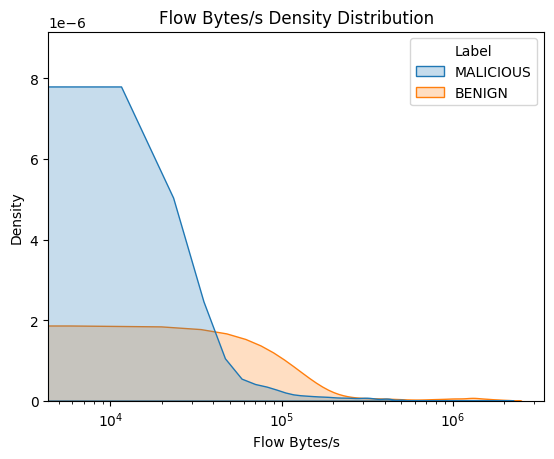

In [ ]:
sns.kdeplot(data=df_sample, x='Flow Bytes/s', hue='Label', fill=True)
plt.xscale('log')
plt.title('Flow Bytes/s Density Distribution')
plt.show()

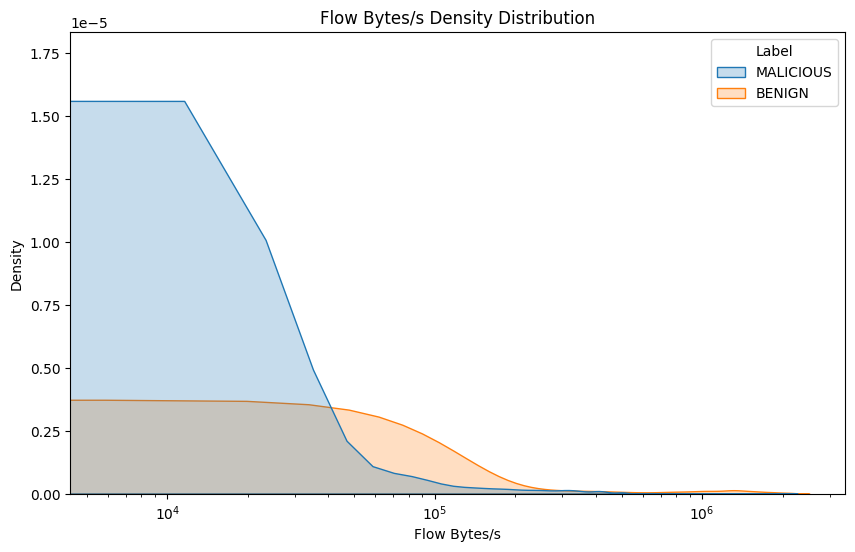

In [ ]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df_sample,
    x='Flow Bytes/s',
    hue='Label',
    fill=True,
    common_norm=False
)

plt.xscale('log')
plt.title('Flow Bytes/s Density Distribution')
plt.show()

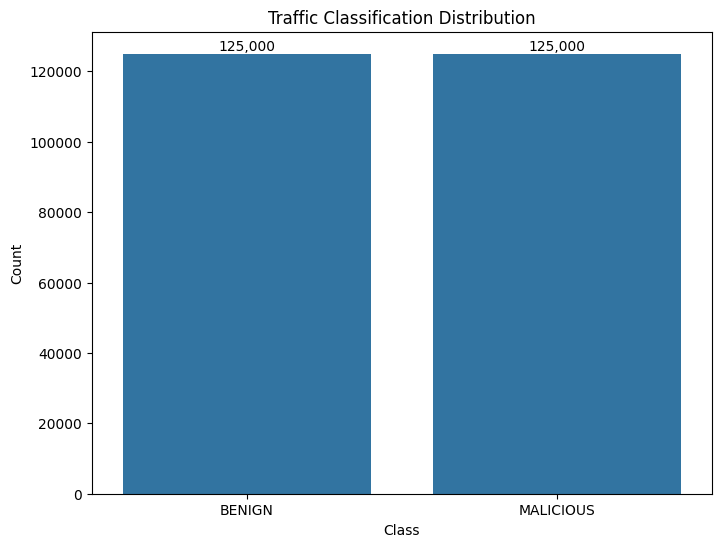

In [ ]:
plt.figure(figsize=(8,6))

counts = df['Label'].value_counts()

sns.barplot(
    x=counts.index,
    y=counts.values
)

plt.title('Traffic Classification Distribution')
plt.xlabel('Class')
plt.ylabel('Count')

# Add labels on top
for i, v in enumerate(counts.values):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.show()

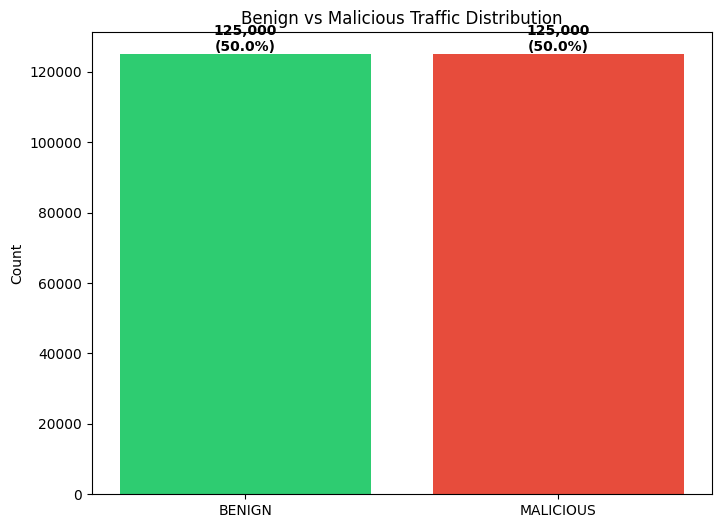

In [ ]:
plt.figure(figsize=(8,6))

counts = df['Label'].value_counts()
colors = ['#2ecc71', '#e74c3c']  # green = benign, red = malicious

plt.bar(counts.index, counts.values, color=colors)

plt.title('Benign vs Malicious Traffic Distribution')
plt.ylabel('Count')

# Add % + count
total = len(df)
for i, v in enumerate(counts.values):
    plt.text(i, v, f"{v:,}\n({v/total*100:.1f}%)",
             ha='center', va='bottom', fontweight='bold')

plt.show()

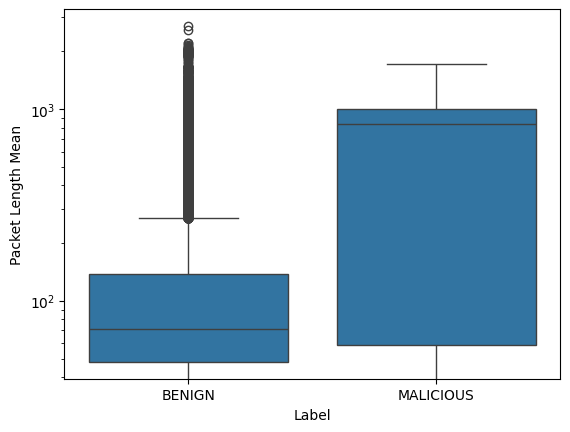

In [ ]:
sns.boxplot(x='Label', y='Packet Length Mean', data=df)
plt.yscale('log')
plt.show()

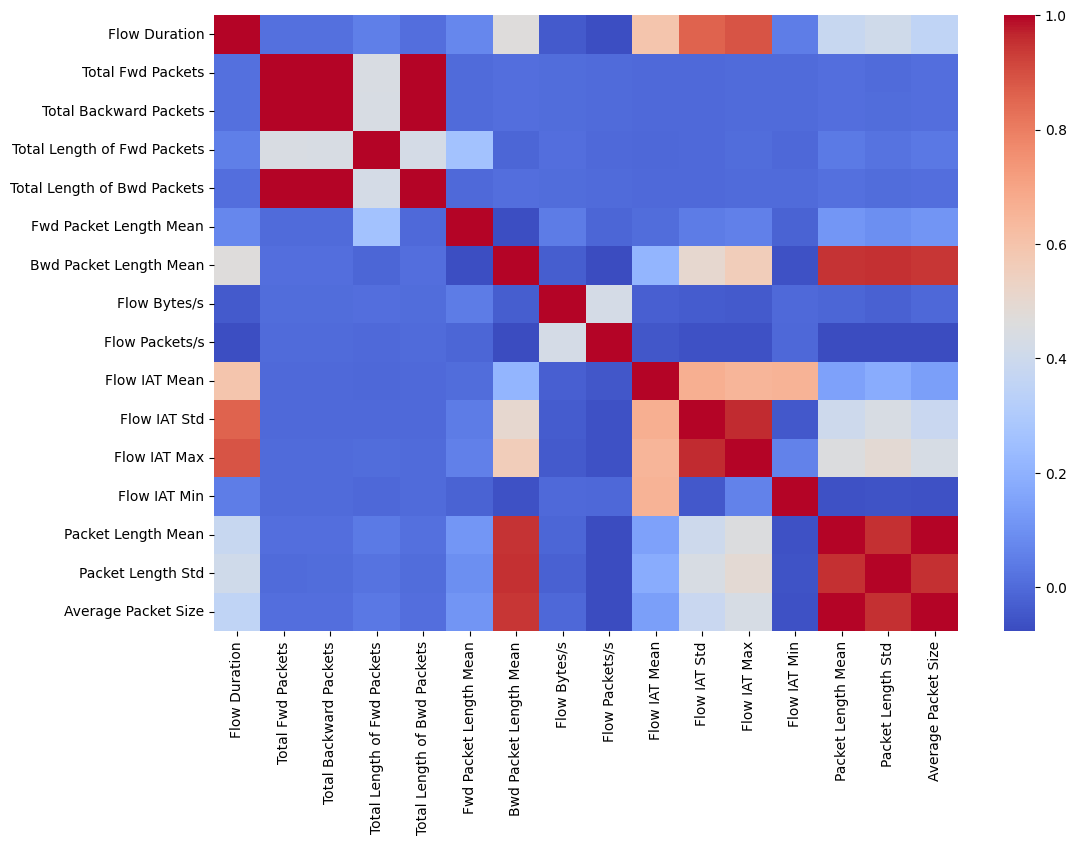

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

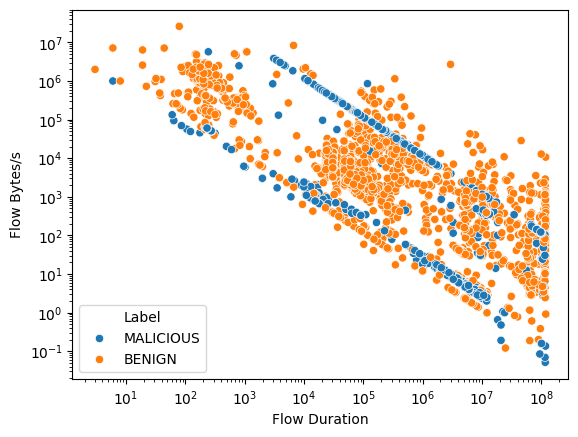

In [ ]:
sample_df = df.sample(5000)

sns.scatterplot(data=sample_df,
                x='Flow Duration',
                y='Flow Bytes/s',
                hue='Label')

plt.xscale('log')
plt.yscale('log')
plt.show()

In [ ]:
data

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Packet Length Mean,Packet Length Std,Average Packet Size,Label
0,23507,2,2,92,254,46.000000,127.00,1.471902e+04,170.162079,7.835667e+03,1.352676e+04,23455,3,78.400000,44.365527,98.000000,Benign
1,52645,3,4,1064,297,354.666667,74.25,2.585241e+04,132.966094,8.774167e+03,1.202066e+04,24456,4,170.125000,375.835237,194.428571,Benign
2,33769,1,1,55,110,55.000000,110.00,4.886138e+03,59.225917,3.376900e+04,0.000000e+00,33769,33769,73.333333,31.754265,110.000000,Benign
3,150,2,2,62,118,31.000000,59.00,1.200000e+06,26666.666670,5.000000e+01,8.573797e+01,149,0,42.200000,15.336232,52.750000,Benign
4,84565,3,6,310,11595,103.333333,1932.50,1.407793e+05,106.427009,1.057062e+04,2.626047e+04,75110,50,1190.500000,1888.989104,1322.777778,Malicious
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,5214727,5,4,794,557,158.800000,139.25,2.590740e+02,1.725881,6.518409e+05,1.667271e+06,4775099,26,135.100000,216.130336,150.111111,Benign
249996,120240,1,1,51,158,51.000000,158.00,1.738190e+03,16.633400,1.202400e+05,0.000000e+00,120240,120240,86.666667,61.776479,130.000000,Benign
249997,154462,3,6,372,11595,124.000000,1932.50,7.747537e+04,58.266758,1.930775e+04,4.905772e+04,140118,4,1196.700000,1885.877223,1329.666667,Malicious
249998,97780719,2,1,486,6,243.000000,6.00,5.031667e+00,0.030681,4.890000e+07,6.910000e+07,97800000,7,123.000000,242.016528,164.000000,Malicious


In [ ]:
data

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Packet Length Mean,Packet Length Std,Average Packet Size,Label
0,23507,2,2,92,254,46.000000,127.00,1.471902e+04,170.162079,7.835667e+03,1.352676e+04,23455,3,78.400000,44.365527,98.000000,Benign
1,52645,3,4,1064,297,354.666667,74.25,2.585241e+04,132.966094,8.774167e+03,1.202066e+04,24456,4,170.125000,375.835237,194.428571,Benign
2,33769,1,1,55,110,55.000000,110.00,4.886138e+03,59.225917,3.376900e+04,0.000000e+00,33769,33769,73.333333,31.754265,110.000000,Benign
3,150,2,2,62,118,31.000000,59.00,1.200000e+06,26666.666670,5.000000e+01,8.573797e+01,149,0,42.200000,15.336232,52.750000,Benign
4,84565,3,6,310,11595,103.333333,1932.50,1.407793e+05,106.427009,1.057062e+04,2.626047e+04,75110,50,1190.500000,1888.989104,1322.777778,Malicious
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,5214727,5,4,794,557,158.800000,139.25,2.590740e+02,1.725881,6.518409e+05,1.667271e+06,4775099,26,135.100000,216.130336,150.111111,Benign
249996,120240,1,1,51,158,51.000000,158.00,1.738190e+03,16.633400,1.202400e+05,0.000000e+00,120240,120240,86.666667,61.776479,130.000000,Benign
249997,154462,3,6,372,11595,124.000000,1932.50,7.747537e+04,58.266758,1.930775e+04,4.905772e+04,140118,4,1196.700000,1885.877223,1329.666667,Malicious
249998,97780719,2,1,486,6,243.000000,6.00,5.031667e+00,0.030681,4.890000e+07,6.910000e+07,97800000,7,123.000000,242.016528,164.000000,Malicious


In [ ]:
data = pd.read_csv("/sample_data.csv")

In [ ]:
numeric_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c != 'is_attack'
]

In [ ]:
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

In [ ]:
zero_var_features = df[numeric_cols].std()[df[numeric_cols].std()==0]

In [ ]:
df['is_attack'] = (df[label_col] != 'BENIGN').astype(int)

Total Numeric Features: 17
Found 0 zero-variance features


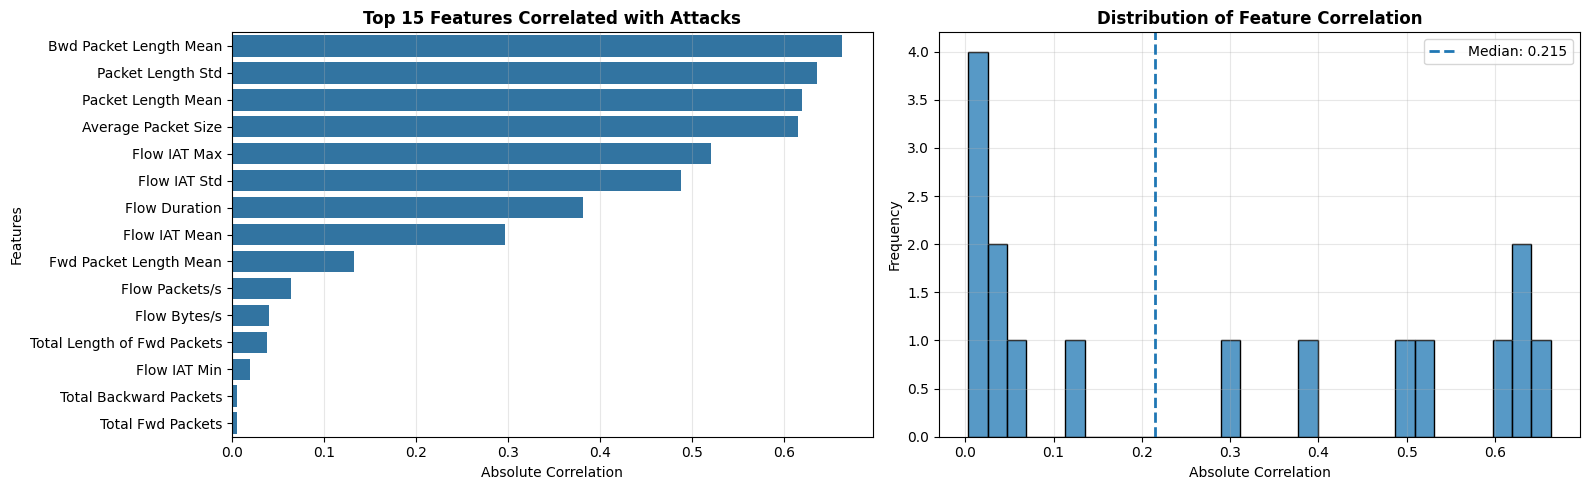


Top 10 Important Features:
Bwd Packet Length Mean    0.663396
Packet Length Std         0.635738
Packet Length Mean        0.619621
Average Packet Size       0.615116
Flow IAT Max              0.520545
Flow IAT Std              0.488493
Flow Duration             0.381959
Flow IAT Mean             0.297450
Fwd Packet Length Mean    0.132588
Flow Packets/s            0.064226
dtype: float64


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure label column is defined
label_col = 'Label'

if not df.empty:

    # -----------------------------
    # 1. Select numeric features
    # -----------------------------
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # -----------------------------
    # 2. Clean data
    # -----------------------------
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=numeric_cols)

    print(f"Total Numeric Features: {len(numeric_cols)}")

    # -----------------------------
    # 3. Remove zero variance features
    # -----------------------------
    zero_var_features = df[numeric_cols].std()
    zero_var_features = zero_var_features[zero_var_features == 0].index.tolist()

    print(f"Found {len(zero_var_features)} zero-variance features")

    if zero_var_features:
        print("Removing:", zero_var_features)
        df = df.drop(columns=zero_var_features)
        numeric_cols = [c for c in numeric_cols if c not in zero_var_features]

    # -----------------------------
    # 4. Create binary target
    # -----------------------------
    df['is_attack'] = (df[label_col] != 'BENIGN').astype(int)

    # -----------------------------
    # 5. Compute correlations
    # -----------------------------
    corr_matrix = df[numeric_cols + ['is_attack']].corr()

    correlations = df[numeric_cols].corrwith(df['is_attack']).abs().sort_values(ascending=False)

    # ✅ REMOVE TARGET FROM RESULTS
    correlations = correlations.drop('is_attack', errors='ignore')

    # -----------------------------
    # 6. Plot graphs
    # -----------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16,5))

    # 🔹 Top 15 features
    top_corr = correlations.head(15)

    sns.barplot(
        x=top_corr.values,
        y=top_corr.index,
        ax=axes[0]
    )

    axes[0].set_title('Top 15 Features Correlated with Attacks', fontweight='bold')
    axes[0].set_xlabel('Absolute Correlation')
    axes[0].set_ylabel('Features')
    axes[0].grid(axis='x', alpha=0.3)

    # 🔹 Correlation distribution
    sns.histplot(correlations.values, bins=30, ax=axes[1])

    axes[1].set_title('Distribution of Feature Correlation', fontweight='bold')
    axes[1].set_xlabel('Absolute Correlation')
    axes[1].set_ylabel('Frequency')

    # median line
    median_val = correlations.median()
    axes[1].axvline(median_val, linestyle='--', linewidth=2, label=f"Median: {median_val:.3f}")
    axes[1].legend()

    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # -----------------------------
    # 7. Print top features
    # -----------------------------
    print("\nTop 10 Important Features:")
    print(correlations.head(10))

Top Features Used for Heatmap:
['Bwd Packet Length Mean', 'Packet Length Std', 'Packet Length Mean', 'Average Packet Size', 'Flow IAT Max', 'Flow IAT Std', 'Flow Duration', 'Flow IAT Mean', 'Fwd Packet Length Mean', 'Flow Packets/s', 'Flow Bytes/s', 'Total Length of Fwd Packets', 'Flow IAT Min', 'Total Backward Packets', 'Total Fwd Packets', 'Total Length of Bwd Packets']


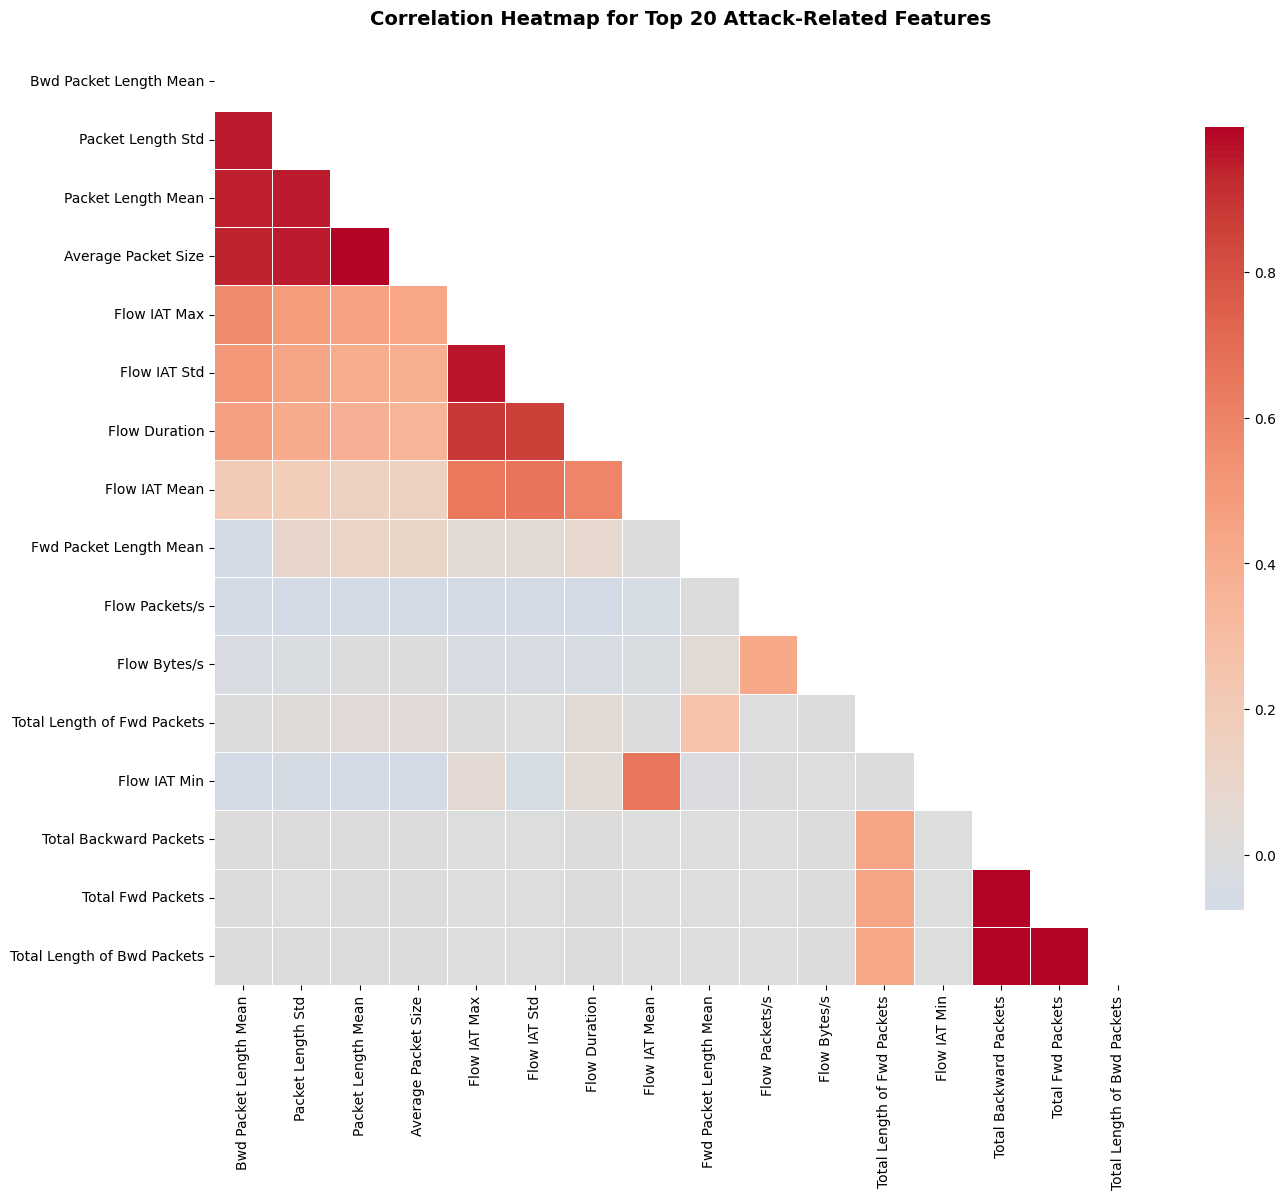


Highly Correlated Feature Pairs (> 0.9):
Bwd Packet Length Mean <-> Packet Length Std: 0.951
Bwd Packet Length Mean <-> Packet Length Mean: 0.948
Bwd Packet Length Mean <-> Average Packet Size: 0.944
Packet Length Std <-> Packet Length Mean: 0.950
Packet Length Std <-> Average Packet Size: 0.951
Packet Length Mean <-> Average Packet Size: 0.999
Flow IAT Max <-> Flow IAT Std: 0.962
Total Backward Packets <-> Total Fwd Packets: 1.000
Total Backward Packets <-> Total Length of Bwd Packets: 1.000
Total Fwd Packets <-> Total Length of Bwd Packets: 1.000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure everything exists
label_col = 'Label'

if not df.empty:

    # -----------------------------
    # 1. Ensure numeric columns
    # -----------------------------
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # Remove target if present
    numeric_cols = [c for c in numeric_cols if c != 'is_attack']

    if len(numeric_cols) > 0:

        # -----------------------------
        # 2. Ensure binary target exists
        # -----------------------------
        if label_col and 'is_attack' not in df.columns:
            df['is_attack'] = (df[label_col] != 'BENIGN').astype(int)

        # -----------------------------
        # 3. Compute correlations with target
        # -----------------------------
        correlations = df[numeric_cols].corrwith(df['is_attack']).abs().sort_values(ascending=False)

        # Remove target if it sneaks in
        correlations = correlations.drop('is_attack', errors='ignore')

        # -----------------------------
        # 4. Select top features
        # -----------------------------
        top_features = correlations.head(20).index.tolist()

        print("Top Features Used for Heatmap:")
        print(top_features)

        # -----------------------------
        # 5. Correlation matrix (feature vs feature)
        # -----------------------------
        corr_matrix = df[top_features].corr()

        # -----------------------------
        # 6. Plot heatmap
        # -----------------------------
        plt.figure(figsize=(14, 12))

        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

        sns.heatmap(
            corr_matrix,
            mask=mask,
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8}
        )

        plt.title(
            'Correlation Heatmap for Top 20 Attack-Related Features',
            fontsize=14,
            fontweight='bold',
            pad=20
        )

        plt.tight_layout()
        plt.show()

        # -----------------------------
        # 7. Detect highly correlated pairs
        # -----------------------------
        print("\nHighly Correlated Feature Pairs (> 0.9):")

        high_corr_pairs = []

        for i in range(len(corr_matrix.columns)):
            for j in range(i + 1, len(corr_matrix.columns)):
                corr_val = corr_matrix.iloc[i, j]

                if abs(corr_val) > 0.9:
                    high_corr_pairs.append(
                        (corr_matrix.columns[i], corr_matrix.columns[j], corr_val)
                    )

        if high_corr_pairs:
            for feat1, feat2, corr_val in high_corr_pairs[:10]:
                print(f"{feat1} <-> {feat2}: {corr_val:.3f}")
        else:
            print("No highly correlated feature pairs found (good for model).")